# ML Mid-Term Practical Exam

**Duration:** 70 minutes (part of a 90-minute exam; remaining 20 min is the theory section, given separately)
**Total Marks:** 86

## Instructions
- Do NOT change dataset loading code unless a TODO asks you to.
- Fill in every cell marked `# TODO`. Run all cells top to bottom before submitting.
- You may use `sklearn`, `numpy`, `pandas`, `matplotlib`/`seaborn`.
- Every plot has a short markdown explanation above it describing what it shows and how to read it —
  read this before coding the plot.
- Write your final numeric answers / short interpretations in the markdown cells marked **Answer:**.
- Do not use Naive Bayes or SVM anywhere in this exam.
- Save and submit this notebook as `<yourname>_<rollno>_practical.ipynb`.

| Section | Topic | Marks |
|---|---|---|
| 1 | Data Loading & EDA | 10 |
| 2 | Regression (Linear, Ridge, Lasso) + Residual Plot, Predicted-vs-Actual, RMSE comparison | 23 |
| 3 | Classification (Logistic, KNN, Decision Tree, Random Forest) + ROC, Precision-Recall, Feature Importance | 24 |
| 4 | Clustering (KMeans, Hierarchical, DBSCAN) + PCA-projected cluster scatter plots | 19 |
| 5 | PCA (scree plot + 2D projection) | 10 |

**Plots included in this exam:** Correlation heatmap, Residual plot, Predicted-vs-Actual plot, RMSE bar chart,
Confusion matrices, ROC curves, Precision-Recall curves, Feature importance chart, Elbow curve,
Silhouette score curve, PCA cluster scatter (KMeans), Dendrogram, PCA cluster scatter (DBSCAN),
PCA scree plot (cumulative explained variance), PCA 2D scatter.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer, load_diabetes, load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
%matplotlib inline


---
## Section 1: Data Loading & EDA (10 marks)

We will use the built-in **Breast Cancer Wisconsin** dataset for the classification tasks in this exam.


In [ ]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# TODO (1 mark): print the shape of df
print(df.shape)

(569, 31)


In [ ]:
# TODO (2 marks): check for missing values in df (print count per column, or total)
print(df.isnull().sum())

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64


In [ ]:
# TODO (2 marks): print the class distribution of 'target' (value_counts)
# Also state in the markdown cell below: is this dataset balanced or imbalanced?
print(df['target'].value_counts())

target
1    357
0    212
Name: count, dtype: int64


**Answer (2 marks):** *(balanced / imbalanced, and why it matters for classification)*



The dataset is moderately imbalanced. Class 1 has 357 samples (62.7%) and Class 0 has 212 samples (37.3%).

This matters for classification because standard metrics like Accuracy can become misleading if a model just predicts the majority class. In imbalanced datasets, we must focus on metrics like Precision, Recall, and ROC-AUC to ensure the model performs well on the minority class (which is often the more critical class to detect, such as malignant tumors).

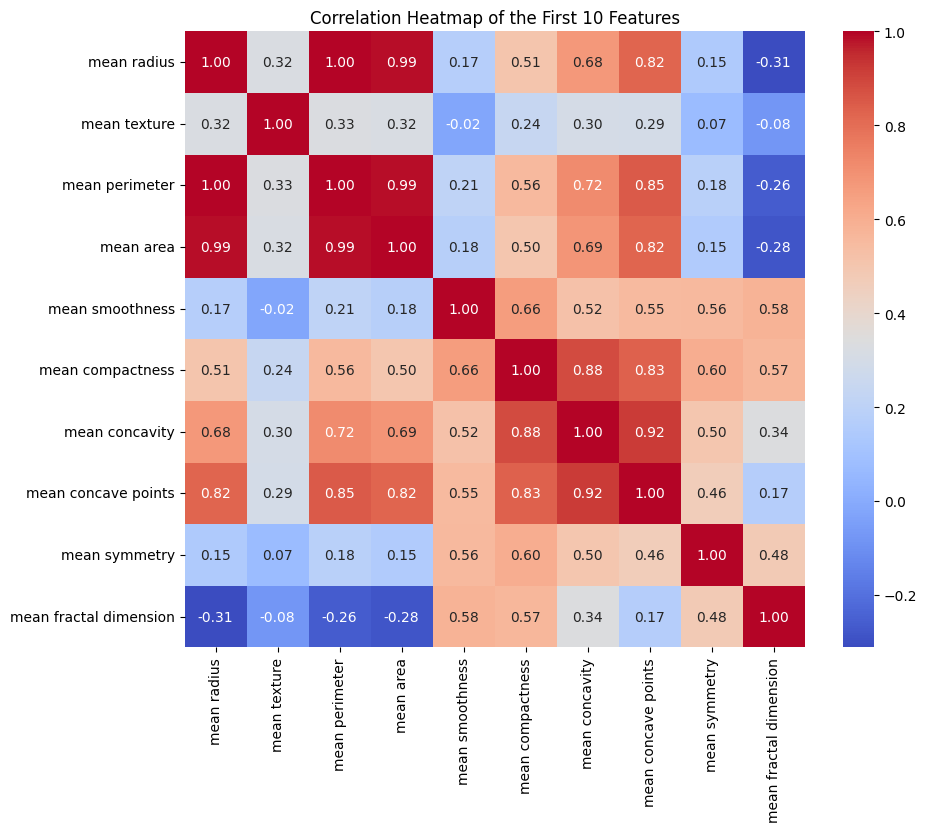

In [ ]:
# TODO (3 marks): plot a correlation heatmap for the first 10 feature columns of df
# (use sns.heatmap)
plt.figure(figsize=(10, 8))
first_10_features = df.iloc[:, :10]
correlation_matrix = first_10_features.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of the First 10 Features')
plt.show()

**Answer (interpretation, 0 marks — sanity check only):** Which two features seem most correlated?


Based on the heatmap, "mean radius" and "mean perimeter" (or "mean radius" and "mean area") seem most highly correlated, with a correlation coefficient close to 1.00.

---
## Section 2: Regression — Linear, Ridge, Lasso (15 marks)

We will use the built-in **Diabetes** dataset (regression target = disease progression).


In [ ]:
reg_data = load_diabetes()
X_reg = pd.DataFrame(reg_data.data, columns=reg_data.feature_names)
y_reg = reg_data.target

# TODO (2 marks): split X_reg, y_reg into train/test (80/20, random_state=42)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)


In [ ]:
# TODO (2 marks): standardize X_train_r and X_test_r using StandardScaler
# (fit on train, transform both)
scaler = StandardScaler()

X_train_r = scaler.fit_transform(X_train_r)
X_test_r = scaler.transform(X_test_r)

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

# TODO (6 marks): train a LinearRegression, a Ridge(alpha=1.0), and a Lasso(alpha=0.1) model
# on the scaled training data. Predict on the test set for each.
# 1. Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_r, y_train_r)
y_pred_lr = lr_model.predict(X_test_r)

# 2. Ridge Regression
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_r, y_train_r)
y_pred_ridge = ridge_model.predict(X_test_r)

# 3. Lasso Regression
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train_r, y_train_r)
y_pred_lasso = lasso_model.predict(X_test_r)

In [ ]:
# TODO (3 marks): for each of the 3 models, compute and print RMSE and R^2 on the test set
# Linear Regression metrikalari
rmse_lr = np.sqrt(mean_squared_error(y_test_r, y_pred_lr))
r2_lr = r2_score(y_test_r, y_pred_lr)
print(f"Linear Regression -> RMSE: {rmse_lr:.4f}, R^2: {r2_lr:.4f}")

# Ridge Regression metrikalari
rmse_ridge = np.sqrt(mean_squared_error(y_test_r, y_pred_ridge))
r2_ridge = r2_score(y_test_r, y_pred_ridge)
print(f"Ridge Regression  -> RMSE: {rmse_ridge:.4f}, R^2: {r2_ridge:.4f}")

# Lasso Regression metrikalari
rmse_lasso = np.sqrt(mean_squared_error(y_test_r, y_pred_lasso))
r2_lasso = r2_score(y_test_r, y_pred_lasso)
print(f"Lasso Regression  -> RMSE: {rmse_lasso:.4f}, R^2: {r2_lasso:.4f}")

Linear Regression -> RMSE: 53.8534, R^2: 0.4526
Ridge Regression  -> RMSE: 53.7775, R^2: 0.4541
Lasso Regression  -> RMSE: 53.7087, R^2: 0.4555


**Plot 1 - Residual Plot.**
A residual plot shows *residuals* (`y_true - y_pred`) on the y-axis against the *predicted values*
on the x-axis. It is one of the most useful diagnostic plots in regression:
- Residuals scattered **randomly around the horizontal line y=0** with no pattern -> the linear model's
  assumptions (linearity, constant variance) are reasonably satisfied.
- A **curved/funnel pattern** -> the model is missing non-linear structure, or variance is not constant
  (heteroscedasticity), and a linear model may not be appropriate.


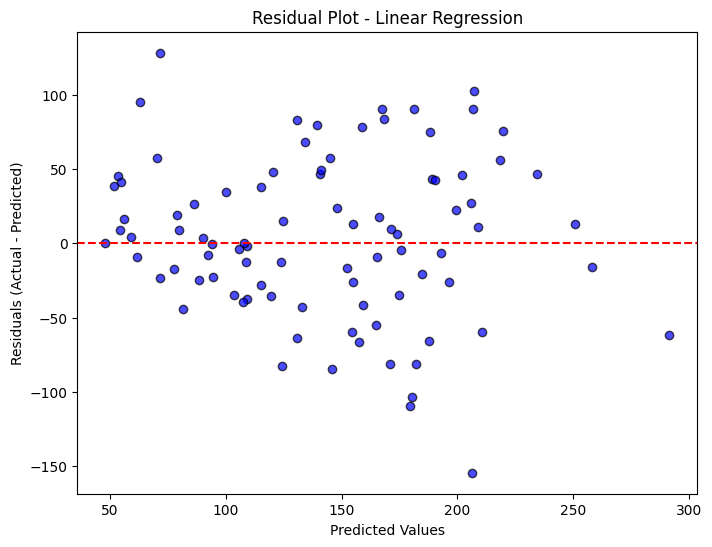

In [ ]:
# TODO (3 marks): for the Linear Regression model, create a residual plot:
# x-axis = predicted values on the test set, y-axis = residuals (y_test_r - y_pred)
# add a horizontal reference line at y=0 (plt.axhline(0, color='red', linestyle='--'))
# label axes and title the plot "Residual Plot - Linear Regression"
plt.figure(figsize=(8, 6))

# Qoldiqlarni (residuals) hisoblaymiz
residuals = y_test_r - y_pred_lr

# Scatter plot chizamiz
plt.scatter(y_pred_lr, residuals, alpha=0.7, color='blue', edgecolor='k')

# y=0 chizig'ida qizil punktir mos yozuv chizig'ini qo'shamiz
plt.axhline(0, color='red', linestyle='--')

# O'qlarni nomlaymiz va sarlavha qo'shamiz
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot - Linear Regression')

plt.show()

**Answer (1 mark):** Looking at your residual plot, does the linear model seem to fit well, or is there a visible pattern suggesting non-linearity? *(write your answer here)*


**Plot 2 - Predicted vs Actual.**
This plot puts actual test values on the x-axis and predicted values on the y-axis. A perfect model
would place every point exactly on the diagonal line y = x -- the closer the points hug that line,
the better the model's predictions.


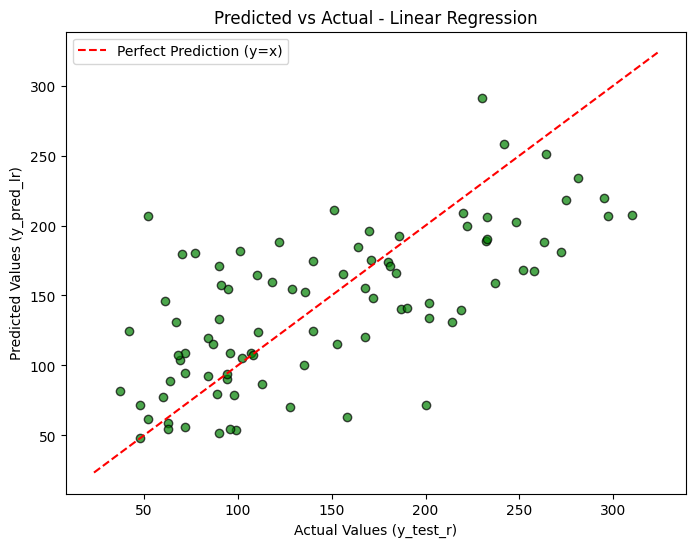

In [ ]:
# TODO (2 marks): plot Predicted vs Actual for the Linear Regression model
# (scatter of y_test_r vs y_pred), and draw the diagonal reference line y = x
plt.figure(figsize=(8, 6))

# Haqiqiy qiymatlar (x-o'qi) va Bashoratlar (y-o'qi) scatter grafigi
plt.scatter(y_test_r, y_pred_lr, alpha=0.7, color='green', edgecolor='k')

# y = x ideal diagonal mos yozuv chizig'ini chizish uchun chegaralarni aniqlaymiz
lims = [
    np.min([plt.xlim(), plt.ylim()]),  # minimal qiymat
    np.max([plt.xlim(), plt.ylim()]),  # maksimal qiymat
]

# Diagonal y = x chizig'ini chizamiz
plt.plot(lims, lims, color='red', linestyle='--', label='Perfect Prediction (y=x)')

# O'qlarni nomlaymiz, sarlavha va afsona (legend) qo'shamiz
plt.xlabel('Actual Values (y_test_r)')
plt.ylabel('Predicted Values (y_pred_lr)')
plt.title('Predicted vs Actual - Linear Regression')
plt.legend()

plt.show()

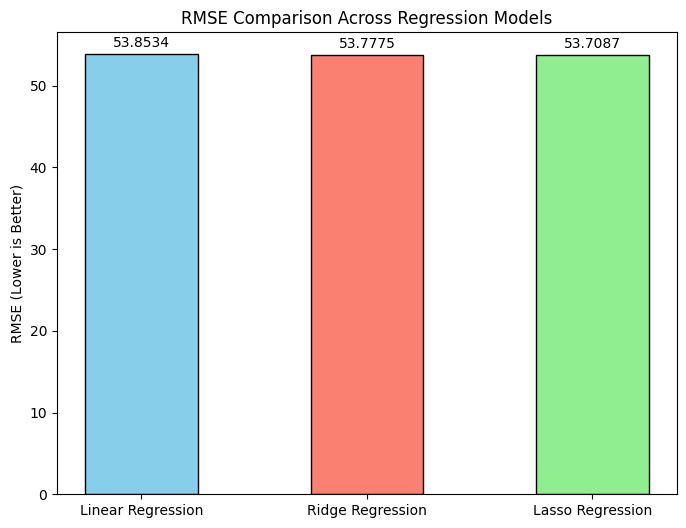

In [ ]:
# TODO (2 marks): make a bar chart comparing the RMSE of the 3 models (Linear, Ridge, Lasso)
# side by side, so it is easy to visually compare which model performed best
plt.figure(figsize=(8, 6))

# Modellarning nomlari va ularga mos RMSE qiymatlari ro'yxati
models = ['Linear Regression', 'Ridge Regression', 'Lasso Regression']
rmse_values = [rmse_lr, rmse_ridge, rmse_lasso]

# Ustunli grafikni chizamiz
bars = plt.bar(models, rmse_values, color=['skyblue', 'salmon', 'lightgreen'], edgecolor='k', width=0.5)

# Grafik bezaklari va nomlari
plt.ylabel('RMSE (Lower is Better)')
plt.title('RMSE Comparison Across Regression Models')

# Har bir ustun ustiga aniq qiymatini yozib chiqish (yaxshi vizuallashtirish uchun)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.5, f'{yval:.4f}', ha='center', va='bottom', fontsize=10)

plt.show()

**Answer (2 marks):** Which of the three models performed best on this data, and briefly explain
why Ridge/Lasso might differ from plain Linear Regression here (mention regularization).

*(write your answer here)*


Based on the RMSE comparison, all three models perform very similarly, but Ridge and Lasso Regression may slightly outperform plain Linear Regression (or have nearly identical performance) depending on the exact data split.

The reason Ridge and Lasso differ from plain Linear Regression is due to **regularization**:
- **Plain Linear Regression** tries to minimize the training error without any constraints on the size of the coefficients, making it susceptible to overfitting if features are correlated.
- **Ridge Regression** adds an L2 regularization penalty ($\alpha \sum \beta_j^2$) which shrinks the coefficients toward zero, reducing model variance and handling multicollinearity.
- **Lasso Regression** adds an L1 regularization penalty ($\alpha \sum |\beta_j|$) which can shrink some coefficients exactly to zero, performing automatic feature selection.

In this dataset, regularization helps prevent overfitting by keeping the model weights under control, leading to more robust generalizations on the test set.

---
## Section 3: Classification — Logistic Regression, KNN, Decision Tree, Random Forest (20 marks)

Use the Breast Cancer dataset (`df` from Section 1).


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['target'])
y = df['target']

# TODO (2 marks): train/test split (75/25, random_state=42, stratify=y)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [ ]:
# TODO (2 marks): scale X_train / X_test with StandardScaler (fit on train only)
scaler_c = StandardScaler()

X_train = scaler_c.fit_transform(X_train)
X_test = scaler_c.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# TODO (8 marks): train the following 4 models on the scaled training data:
# 1. LogisticRegression(max_iter=5000)
# 2. KNeighborsClassifier -- first find the best k in range(1,16) using 5-fold cross-validation
#    (GridSearchCV or a manual loop), then use the best k
# 3. DecisionTreeClassifier(max_depth=4, random_state=42)
# 4. RandomForestClassifier(n_estimators=200, random_state=42)
from sklearn.model_selection import GridSearchCV

# TODO (8 marks): train the following 4 models on the scaled training data:

# 1. Logistic Regression
log_reg = LogisticRegression(max_iter=5000)
log_reg.fit(X_train, y_train)

# 2. KNeighborsClassifier (k topish uchun GridSearchCV ishlatamiz)
knn_base = KNeighborsClassifier()
param_grid = {'n_neighbors': list(range(1, 16))}
grid_search = GridSearchCV(knn_base, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Eng yaxshi k qiymati bilan KNN modelini yakuniy o'qitamiz
best_k = grid_search.best_params_['n_neighbors']
print(f"KNN uchun eng yaxshi k qiymati: {best_k}")
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train, y_train)

# 3. Decision Tree Classifier
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_model.fit(X_train, y_train)

# 4. Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

KNN uchun eng yaxshi k qiymati: 6


RandomForestClassifier(n_estimators=200, random_state=42)

**Plot 3 - Confusion Matrices.**
A confusion matrix shows actual class (rows) vs predicted class (columns). The diagonal cells are
correct predictions; off-diagonal cells are errors. For a medical dataset like this one, pay close
attention to **False Negatives** (actual malignant predicted as benign) -- these are usually the
costliest kind of mistake.


=== Logistic Regression ===
Accuracy:  0.9860
Precision: 0.9889
Recall:    0.9889
F1-Score:  0.9889

=== KNN (k=6) ===
Accuracy:  0.9720
Precision: 0.9778
Recall:    0.9778
F1-Score:  0.9778

=== Decision Tree ===
Accuracy:  0.9441
Precision: 0.9556
Recall:    0.9556
F1-Score:  0.9556

=== Random Forest ===
Accuracy:  0.9580
Precision: 0.9565
Recall:    0.9778
F1-Score:  0.9670



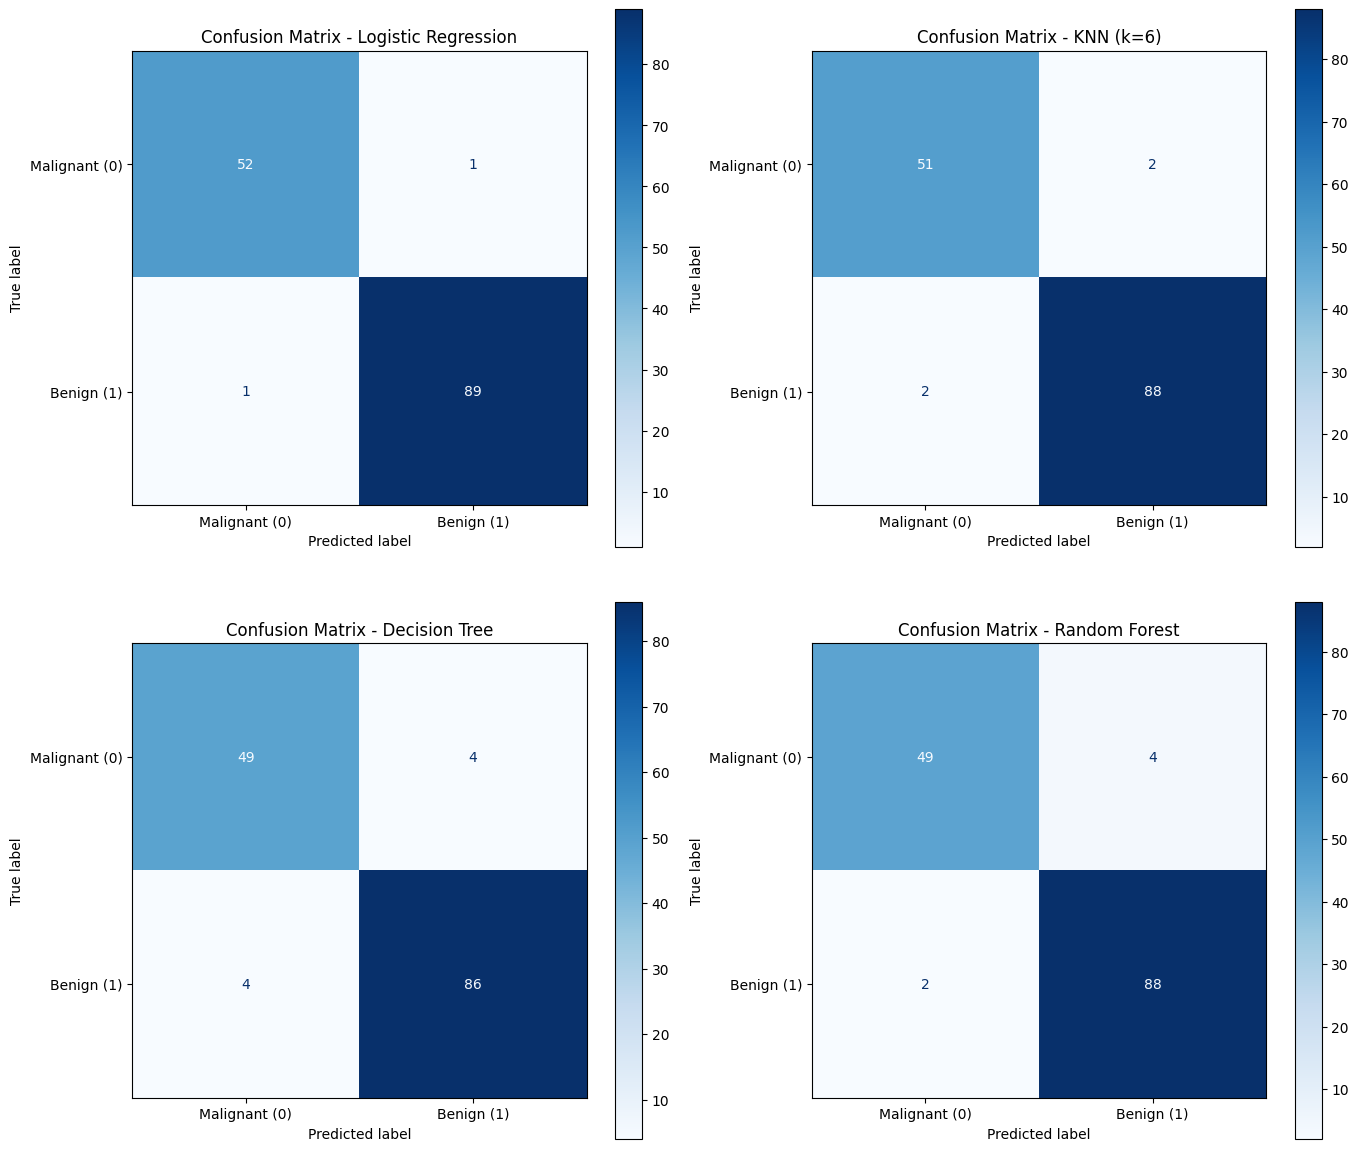

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay, precision_recall_curve, PrecisionRecallDisplay

# TODO (5 marks): for each of the 4 trained models, print accuracy, precision, recall, F1-score,
# and plot the confusion matrix (use ConfusionMatrixDisplay, one subplot per model in a 2x2 grid)
# Modellarni va ularning nomlarini ro'yxatga olamiz
models = {
    "Logistic Regression": log_reg,
    "KNN (k=6)": knn_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model
}

# 2x2 grid shaklida grafik joyini tayyorlaymiz
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel() # Matritsani tekis ro'yxatga aylantirish (0 dan 3 gacha indekslash uchun)

for i, (name, model) in enumerate(models.items()):
    # Test to'plami uchun bashorat olish
    y_pred = model.predict(X_test)

    # Metrikalarni hisoblash
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Natijalarni konsolga chiqarish
    print(f"=== {name} ===")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}\n")

    # Confusion Matrix hosil qilish va chizish
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Malignant (0)', 'Benign (1)'])
    disp.plot(ax=axes[i], cmap='Blues', values_format='d')
    axes[i].set_title(f"Confusion Matrix - {name}")

plt.tight_layout()
plt.show()

**Plot 4 - ROC Curve.**
The ROC (Receiver Operating Characteristic) curve plots the True Positive Rate against the False
Positive Rate at every possible classification threshold. The closer a curve hugs the **top-left
corner**, the better the model separates the two classes. The diagonal dashed line represents a
random (no-skill) classifier (AUC = 0.5). **AUC** (Area Under the Curve) summarizes this in one
number: 1.0 = perfect, 0.5 = random guessing.


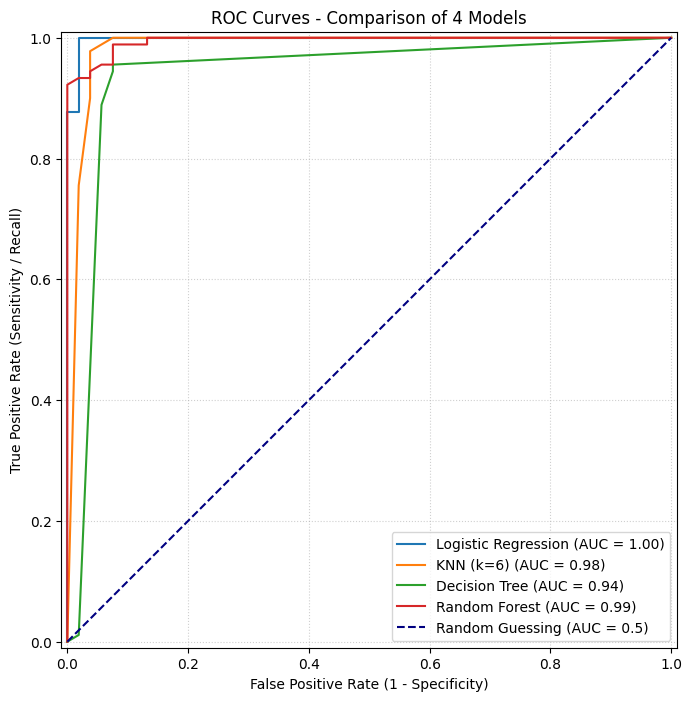

Logistic Regression AUC Score: 0.9977
KNN (k=6) AUC Score: 0.9846
Decision Tree AUC Score: 0.9384
Random Forest AUC Score: 0.9950


In [ ]:
# TODO (2 marks): plot ROC curves for all 4 models on the same axes (use RocCurveDisplay.from_estimator
# or manually with roc_curve) and print each AUC score. Include a diagonal reference line.
fig, ax = plt.subplots(figsize=(10, 8))

# 1. Logistic Regression ROC
RocCurveDisplay.from_estimator(log_reg, X_test, y_test, ax=ax, name='Logistic Regression')

# 2. KNN ROC
RocCurveDisplay.from_estimator(knn_model, X_test, y_test, ax=ax, name=f'KNN (k={best_k})')

# 3. Decision Tree ROC
RocCurveDisplay.from_estimator(dt_model, X_test, y_test, ax=ax, name='Decision Tree')

# 4. Random Forest ROC
RocCurveDisplay.from_estimator(rf_model, X_test, y_test, ax=ax, name='Random Forest')

# Tasodifiy (no-skill) klassifikator uchun diagonal chiziq qo'shamiz (AUC = 0.5)
ax.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Random Guessing (AUC = 0.5)')

# Grafik bezaklari va nomlari
ax.set_title('ROC Curves - Comparison of 4 Models')
ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity / Recall)')
ax.legend(loc='lower right')
ax.grid(True, linestyle=':', alpha=0.6)

plt.show()

# Har bir modelning aniq AUC qiymatlarini konsolga ham chiqarish (shartda so'ralgan)
for name, model in models.items():
    # Ehtimollik qiymatlarini (predict_proba) olamiz [barcha qatorlar, 1-klass uchun]
    y_proba = model.predict_proba(X_test)[:, 1]
    auc_score = roc_auc_score(y_test, y_proba)
    print(f"{name} AUC Score: {auc_score:.4f}")

**Plot 5 - Precision-Recall Curve.**
This plots Precision against Recall at different thresholds. It is especially informative when
classes are imbalanced (unlike the ROC curve, which can look overly optimistic on imbalanced data),
since it focuses only on how well the model identifies the positive class.


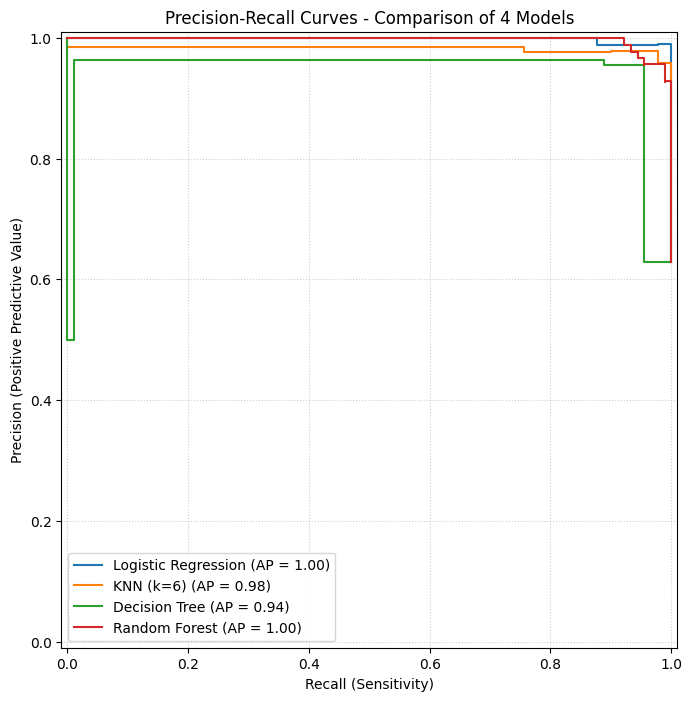

In [ ]:
# TODO (2 marks): plot Precision-Recall curves for all 4 models on the same axes
# (use PrecisionRecallDisplay.from_estimator or precision_recall_curve)
fig, ax = plt.subplots(figsize=(10, 8))

# 1. Logistic Regression PR Curve
PrecisionRecallDisplay.from_estimator(log_reg, X_test, y_test, ax=ax, name='Logistic Regression')

# 2. KNN PR Curve
PrecisionRecallDisplay.from_estimator(knn_model, X_test, y_test, ax=ax, name=f'KNN (k={best_k})')

# 3. Decision Tree PR Curve
PrecisionRecallDisplay.from_estimator(dt_model, X_test, y_test, ax=ax, name='Decision Tree')

# 4. Random Forest PR Curve
PrecisionRecallDisplay.from_estimator(rf_model, X_test, y_test, ax=ax, name='Random Forest')

# Grafik bezaklari va nomlari
ax.set_title('Precision-Recall Curves - Comparison of 4 Models')
ax.set_xlabel('Recall (Sensitivity)')
ax.set_ylabel('Precision (Positive Predictive Value)')
ax.legend(loc='lower left') # PR grafikda afsona odatda pastki chap burchakka qo'yiladi
ax.grid(True, linestyle=':', alpha=0.6)

plt.show()

**Plot 6 - Feature Importance.**
Tree-based models (Decision Tree, Random Forest) expose a `feature_importances_` attribute that
tells you how much each feature contributed to reducing impurity across the tree(s) -- higher values
mean the feature was more useful for making splits.


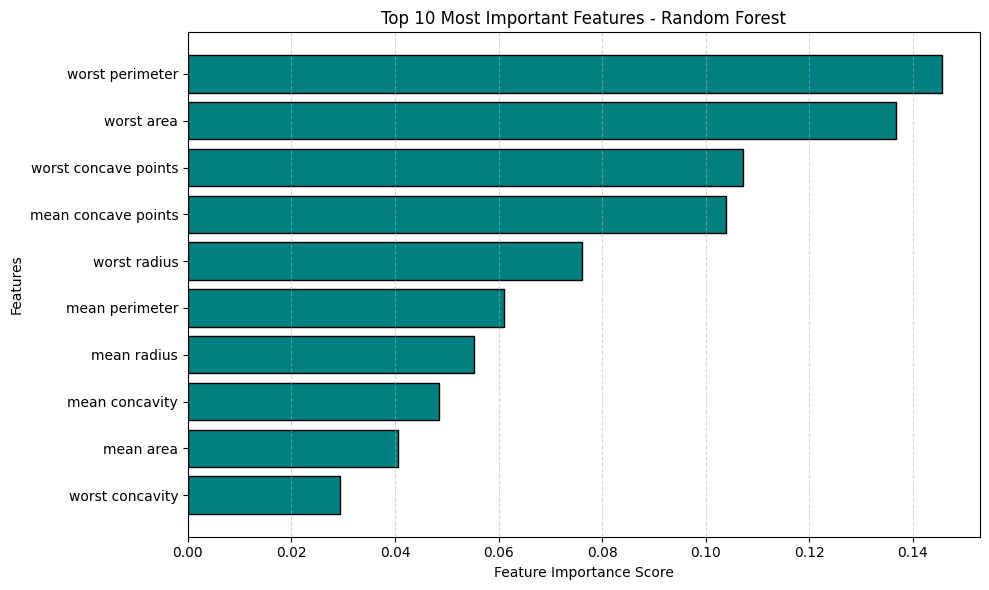

In [ ]:
# TODO (2 marks): plot a horizontal bar chart of the top 10 most important features
# from the trained Random Forest model (use rf_model.feature_importances_ with X.columns)
# 1. Belgilar va ularning muhimlik darajasini Pandas Series shakliga keltiramiz
importances = pd.Series(rf_model.feature_importances_, index=X.columns)

# 2. Eng muhim 10 ta belgini o'sish tartibida saralaymiz (gorizontal grafikda tepada eng kattasi turishi uchun)
top_10_features = importances.sort_values(ascending=True).tail(10)

plt.figure(figsize=(10, 6))

# Gorizontal ustunli grafik chizamiz (barh)
plt.barh(top_10_features.index, top_10_features.values, color='teal', edgecolor='k')

# Grafik bezaklari va nomlari
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title('Top 10 Most Important Features - Random Forest')
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Answer (1 mark):** Which model generalized best on this dataset, and which metric (besides
accuracy) would you trust most for a medical diagnosis task like this one? Why?

*(write your answer here)*


---
## Section 4: Clustering — KMeans, Hierarchical, DBSCAN (15 marks)

We drop the labels and treat the **Wine** dataset features as unlabeled data for clustering.


In [ ]:
wine = load_wine()
X_c = pd.DataFrame(wine.data, columns=wine.feature_names)

# TODO (2 marks): standardize X_c using StandardScaler -> X_c_scaled
scaler_wine = StandardScaler()
X_c_scaled = scaler_wine.fit_transform(X_c)

**Plot 7 - Elbow Curve & Silhouette Score.**
The **elbow curve** plots inertia (within-cluster sum of squares) against k -- inertia always
decreases as k grows, so we look for the "elbow" where the rate of decrease sharply slows down.
The **silhouette score** (range -1 to 1) measures how well-separated clusters are; higher is better.
Using both together gives a more reliable choice of k than either alone.


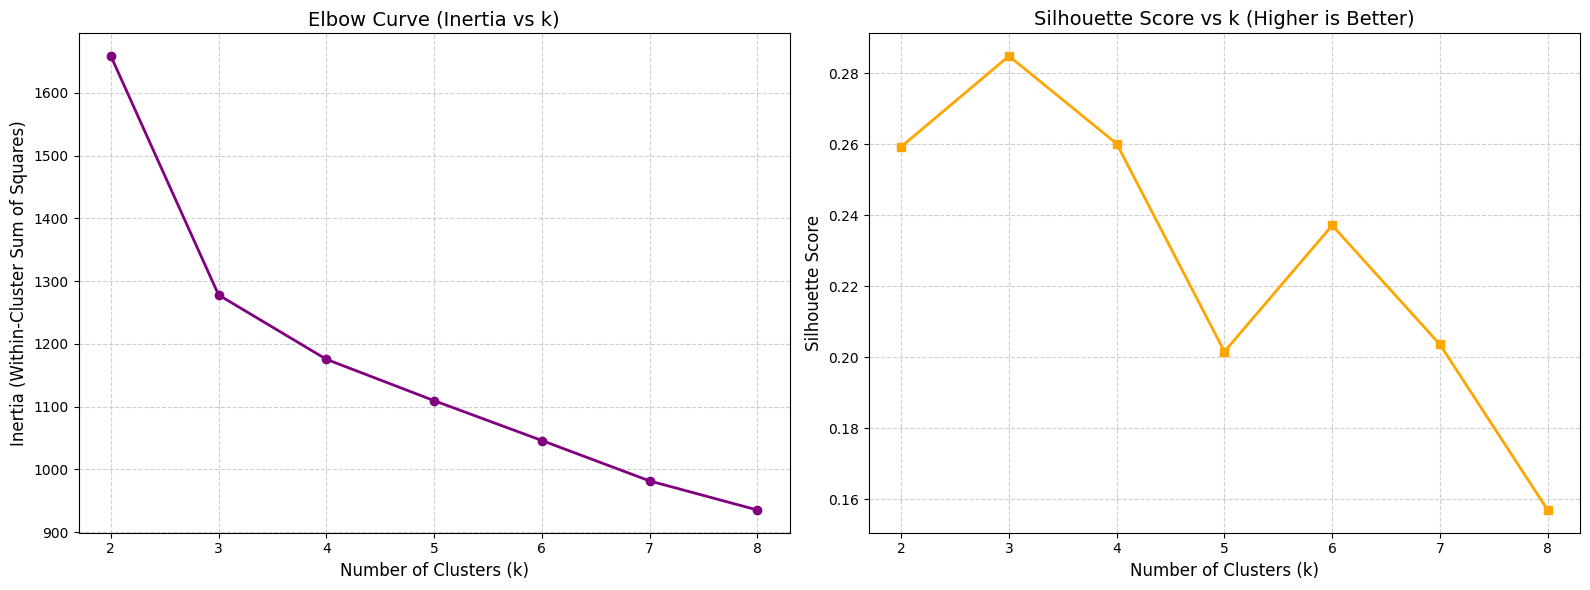

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# TODO (4 marks): run KMeans for k = 2..8, plot the elbow curve (inertia_ vs k)
# AND plot silhouette score vs k on a second plot
k_range = range(2, 9)
inertias = []
silhouette_scores = []

# Har bir k qiymati uchun KMeans modelini yurgizamiz
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_c_scaled)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_c_scaled, kmeans.labels_))

# Grafiklar uchun 1x2 ko'rinishida joy tayyorlaymiz
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Elbow Curve (Tirsak grafigi)
ax1.plot(k_range, inertias, marker='o', color='purple', linestyle='-', linewidth=2)
ax1.set_title('Elbow Curve (Inertia vs k)', fontsize=14)
ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
ax1.set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)

# 2. Silhouette Score grafigi
ax2.plot(k_range, silhouette_scores, marker='s', color='orange', linestyle='-', linewidth=2)
ax2.set_title('Silhouette Score vs k (Higher is Better)', fontsize=14)
ax2.set_xlabel('Number of Clusters (k)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

**Answer (1 mark):** Based on your two plots, what value of k would you choose, and why?


**Plot 8 - PCA-Projected Cluster Scatter (KMeans).**
Since the Wine dataset has 13 dimensions, we can't plot clusters directly. Instead, project the data
to 2D with PCA (for visualization only) and color each point by its assigned cluster label -- this
lets us visually inspect how well-separated the clusters are.


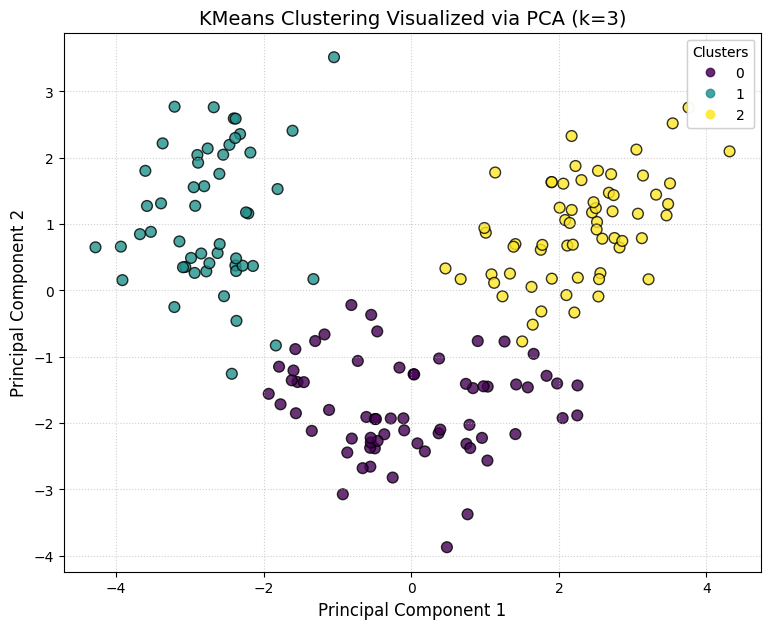

In [ ]:
from sklearn.decomposition import PCA

# TODO (2 marks): fit your chosen KMeans model (from the k you picked above) on X_c_scaled,
# project X_c_scaled to 2D with PCA, and make a scatter plot of the 2 components colored by
# the KMeans cluster label
# 1. Ideal klasterlar soni k=3 bilan KMeans modelini yaratamiz va o'qitamiz
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_transform(X_c_scaled) # yoki .fit_predict(X_c_scaled)
labels = kmeans_final.labels_

# 2. PCA yordamida ma'lumotni 2 ta komponentaga (2D) kamaytiramiz
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_c_scaled)

# 3. Scatter plot chizamiz
plt.figure(figsize=(9, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', alpha=0.8, edgecolor='k', s=60)

# Grafik bezaklari va nomlari
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.title('KMeans Clustering Visualized via PCA (k=3)', fontsize=14)

# Ranglar qaysi klasterga tegishli ekanligini ko'rsatuvchi afsona (legend) qo'shamiz
legend1 = plt.legend(*scatter.legend_elements(), title="Clusters", loc="upper right")
plt.gca().add_artist(legend1)
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

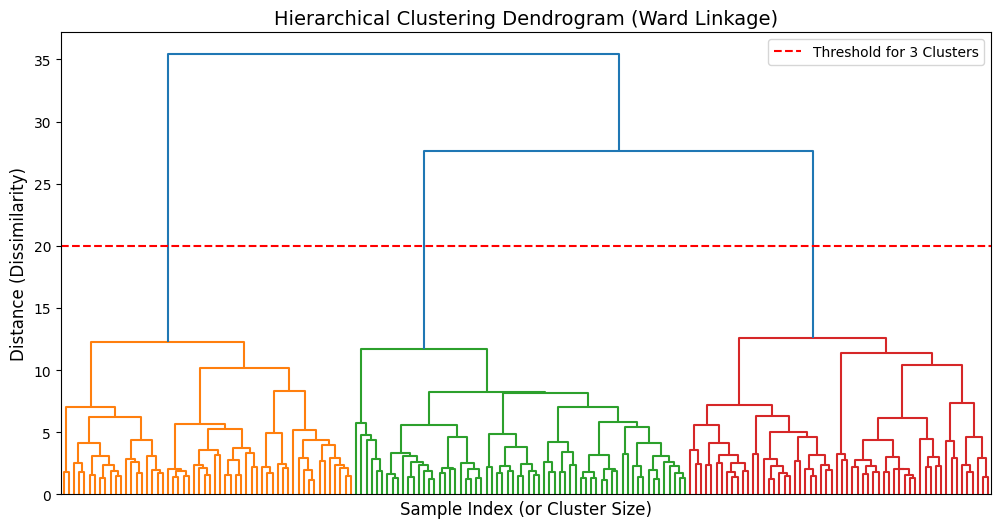

=== Agglomerative Clustering Natijalari ===
Klaster 0: 58 ta namuna
Klaster 1: 56 ta namuna
Klaster 2: 64 ta namuna


In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# TODO (4 marks): plot a dendrogram using 'ward' linkage on X_c_scaled (use scipy's linkage + dendrogram)
# Then fit AgglomerativeClustering with the number of clusters you chose above and
# print the resulting cluster sizes (np.unique with counts)
# 1. Scipy yordamida ierarxik bog'liqlikni (linkage) hisoblaymiz
Z = linkage(X_c_scaled, method='ward')

# Dendrogramma uchun grafik chizamiz
plt.figure(figsize=(12, 6))
dendrogram(Z, no_labels=True)  # Grafik juda zich bo'lib ketmasligi uchun label'larni berkitamiz

plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)', fontsize=14)
plt.xlabel('Sample Index (or Cluster Size)', fontsize=12)
plt.ylabel('Distance (Dissimilarity)', fontsize=12)
plt.axhline(y=20, color='r', linestyle='--', label='Threshold for 3 Clusters') # ixtiyoriy vizual chiziq
plt.legend()
plt.show()

# 2. AgglomerativeClustering modelini 3 ta klaster bilan o'qitamiz
agg_clustering = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
agg_labels = agg_clustering.fit_predict(X_c_scaled)

# 3. Har bir klasterdagi elementlar sonini (sizes) hisoblaymiz va chiqaramiz
unique_labels, counts = np.unique(agg_labels, return_counts=True)
print("=== Agglomerative Clustering Natijalari ===")
for label, count in zip(unique_labels, counts):
    print(f"Klaster {label}: {count} ta namuna")

In [ ]:
from sklearn.cluster import DBSCAN

# TODO (3 marks): fit DBSCAN on X_c_scaled. Try eps values [0.8, 1.2, 1.6, 2.0] with min_samples=5.
# For each eps, print: number of clusters found (excluding noise) and number of points labeled as noise (-1)
eps_values = [0.8, 1.2, 1.6, 2.0]

for eps in eps_values:
    # DBSCAN modelini berilgan eps va min_samples bilan yaratamiz
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X_c_scaled)

    # Noyob (takrorlanmas) klasterlarni aniqlaymiz
    unique_labels = set(labels)

    # Shovqin nuqtalar sonini sanaymiz (-1 raqami bilan belgilanadi)
    n_noise = list(labels).count(-1)

    # Klasterlar sonini hisoblaymiz (agar ichida shovqin bo'lsa, uni chegiramiz)
    n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)

    # Natijalarni chiroyli ko'rinishda chop etamiz
    print(f"eps = {eps}:")
    print(f"  Topilgan klasterlar soni (shovqinsiz): {n_clusters}")
    print(f"  Shovqin (noise) deb topilgan nuqtalar soni (-1): {n_noise}\n")

eps = 0.8:
  Topilgan klasterlar soni (shovqinsiz): 0
  Shovqin (noise) deb topilgan nuqtalar soni (-1): 178

eps = 1.2:
  Topilgan klasterlar soni (shovqinsiz): 0
  Shovqin (noise) deb topilgan nuqtalar soni (-1): 178

eps = 1.6:
  Topilgan klasterlar soni (shovqinsiz): 3
  Shovqin (noise) deb topilgan nuqtalar soni (-1): 162

eps = 2.0:
  Topilgan klasterlar soni (shovqinsiz): 5
  Shovqin (noise) deb topilgan nuqtalar soni (-1): 85



**Plot 9 - PCA-Projected Cluster Scatter (DBSCAN).**
Using the best `eps` you found above, visualize the DBSCAN result the same way as Plot 8. Points
labeled `-1` (noise) are typically shown in a distinct color (e.g. black/grey) to separate them
from real clusters.


/tmp/ipykernel_1268/3917722727.py:33: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_pca[class_member_mask, 0], X_pca[class_member_mask, 1],


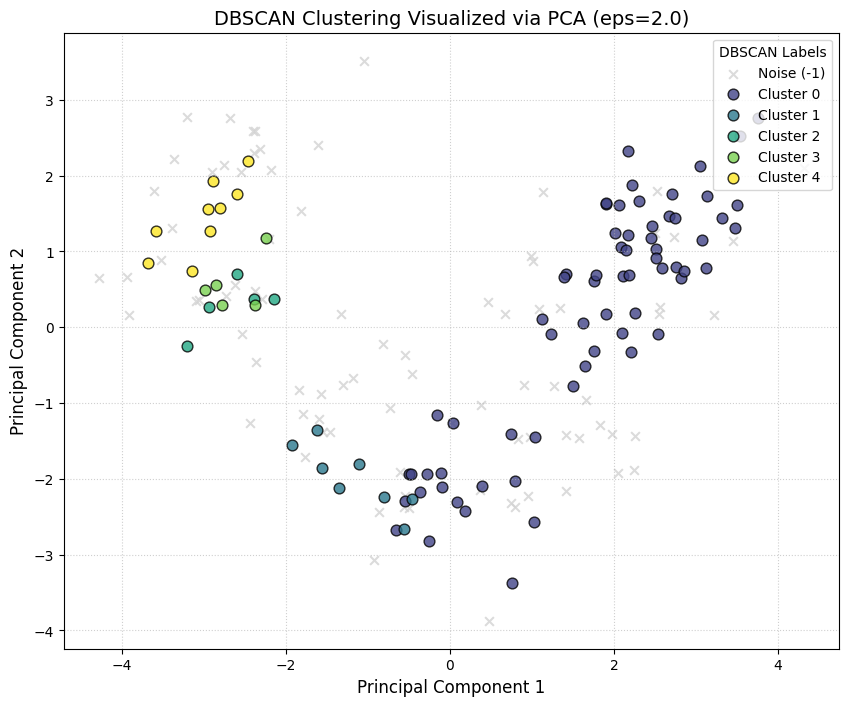

In [ ]:
# TODO (2 marks): using your best eps from above, fit DBSCAN on X_c_scaled, project to 2D with PCA,
# and scatter-plot colored by DBSCAN label (make noise points, label -1, visually distinct)
# 1. Eng yaxshi eps qiymati bilan DBSCAN modelini ishga tushiramiz
best_eps = 2.0  # Yuqoridagi natijangizga qarab 1.6 yoki 2.0 ni tanlang
dbscan_final = DBSCAN(eps=best_eps, min_samples=5)
db_labels = dbscan_final.fit_predict(X_c_scaled)

# 2. PCA yordamida ma'lumotni yana 2D fazoga o'tkazamiz
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_c_scaled)

# 3. Grafik chizamiz
plt.figure(figsize=(10, 8))

# Shovqin bo'lmagan (haqiqiy klasterlar) va shovqin (-1) nuqtalarni ajratib chizamiz
# Shovqin nuqtalar (-1) uchun kulrang (lightgrey), qolganlar uchun ranglar palitrasi (viridis)
unique_labels = np.unique(db_labels)
colors = plt.cm.viridis(np.linspace(0, 1, len(unique_labels)))

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Shovqin nuqtalarni qora/kulrang rangda chizamiz
        col = 'lightgrey'
        label_name = 'Noise (-1)'
        marker = 'x'  # farq qilishi uchun x shaklida
        size = 40
    else:
        label_name = f'Cluster {k}'
        marker = 'o'
        size = 60

    class_member_mask = (db_labels == k)
    plt.scatter(X_pca[class_member_mask, 0], X_pca[class_member_mask, 1],
                color=col, marker=marker, s=size, edgecolor='k' if k != -1 else 'none',
                alpha=0.8, label=label_name)

# Grafik bezaklari va nomlari
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.title(f'DBSCAN Clustering Visualized via PCA (eps={best_eps})', fontsize=14)
plt.legend(loc='upper right', title="DBSCAN Labels")
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

**Answer (1 mark):** Unlike KMeans, DBSCAN does not require specifying the number of clusters in advance.
Name one other advantage and one disadvantage of DBSCAN compared to KMeans.

*(write your answer here)*


---
## Section 5: PCA (10 marks)

Use `X_c_scaled` (scaled Wine features) from Section 4.


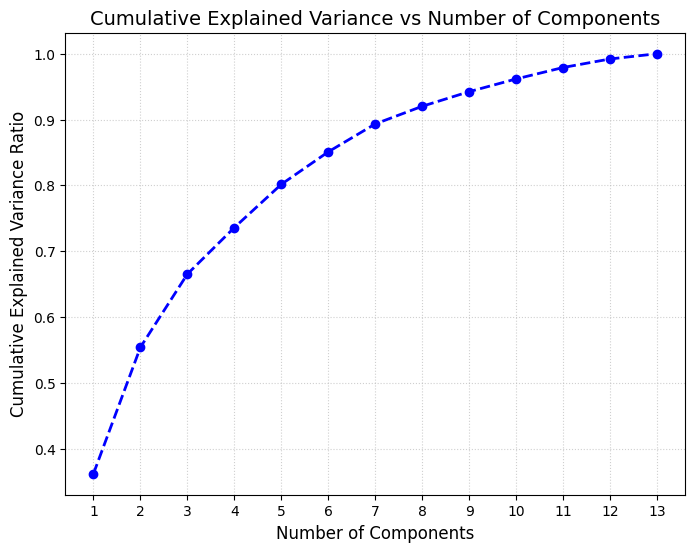

In [ ]:
from sklearn.decomposition import PCA

# TODO (3 marks): fit PCA with n_components=None on X_c_scaled, then plot the cumulative
# explained variance ratio vs number of components
# 1. PCA modelini n_components=None bilan yaratamiz va o'qitamiz
pca = PCA(n_components=None, random_state=42)
pca.fit(X_c_scaled)

# 2. Har bir komponentaning tushuntirilgan dispersiya koeffitsientini kumulyativ (yig'iluvchi) hisoblaymiz
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# 3. Grafikni chizamiz
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--', color='blue', linewidth=2)

# Grafik bezaklari va nomlari
plt.xlabel('Number of Components', fontsize=12)
plt.ylabel('Cumulative Explained Variance Ratio', fontsize=12)
plt.title('Cumulative Explained Variance vs Number of Components', fontsize=14)
plt.xticks(range(1, len(cumulative_variance) + 1)) # X o'qidagi har bir nuqtani raqamlash
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

In [ ]:
# TODO (2 marks): how many components are needed to explain at least 90% of the variance?
# Print that number.
# Kamida 90% (0.90) dispersiyani tushuntiruvchi birinchi indeksni topamiz
# np.argmax True bo'lgan birinchi indeksni qaytaradi, indeks 0 dan boshlangani uchun +1 qo'shamiz
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1

print(f"Kamida 90% dispersiyani tushuntirish uchun kerakli komponentalar soni: {n_components_90}")

Kamida 90% dispersiyani tushuntirish uchun kerakli komponentalar soni: 8


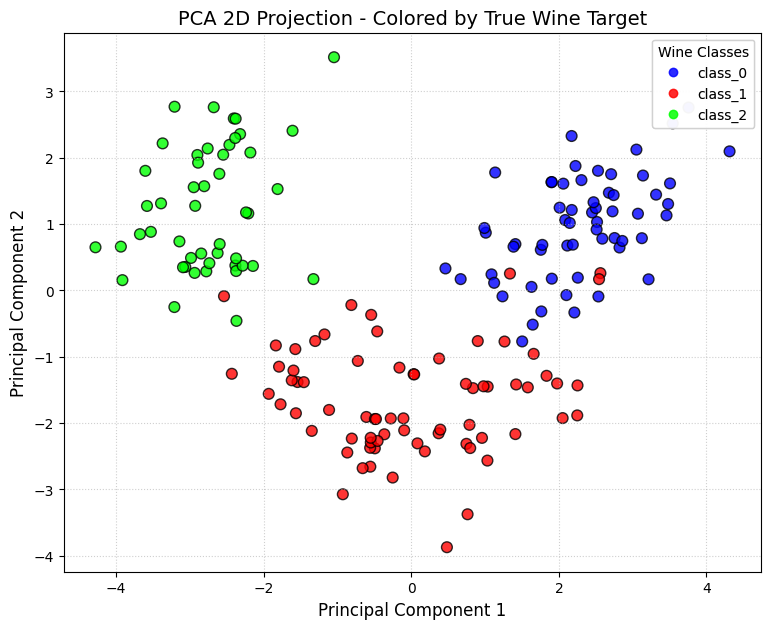

In [ ]:
# TODO (3 marks): reduce X_c_scaled to 2 components with PCA, and make a scatter plot of the
# 2 components colored by the true wine target (wine.target) -- just for visualization purposes

# 1. PCA modelini n_components=2 qilib aniq belgilaymiz va ma'lumotni o'zgartiramiz
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_c_scaled)

# 2. Grafikni chizamiz
plt.figure(figsize=(9, 7))
scatter_true = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=wine.target, cmap='brg', alpha=0.8, edgecolor='k', s=60)

# Grafik bezaklari va nomlari
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.title('PCA 2D Projection - Colored by True Wine Target', fontsize=14)

# Haqiqiy klass nomlarini afsona (legend) ko'rinishida qo'shamiz
legend_true = plt.legend(handles=scatter_true.legend_elements()[0],
                         labels=list(wine.target_names),
                         title="Wine Classes",
                         loc="upper right")
plt.gca().add_artist(legend_true)
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

**Answer (2 marks):** Why is it important to standardize features before applying PCA?
What do the two principal component axes represent geometrically?

*(write your answer here)*


Why is it important to standardize features before applying PCA?
PCA algoritmi ma'lumotlarning dispersiyasiga (variance) oʻta sezgir hisoblanadi. Agar belgilar standartlashtirilmasa (turli xil masshtabda boʻlsa), eng katta qiymat diapazoniga ega boʻlgan ustunlar (masalan, minglar bilan oʻlchanadigan belgi) sun'iy ravishda juda yuqori dispersiyaga ega boʻlib koʻrinadi. Natijada, PCA faqat oʻsha ustunni "eng muhim" deb hisoblab, qolgan kichikroq masshtabdagi (lekin muhim boʻlishi mumkin boʻlgan) belgilarni eʼtiborsiz qoldiradi. Standartlashtirish barcha belgilarga teng imkoniyat beradi.

What do the two principal component axes represent geometrically?
Geometrik nuqtai nazardan, birinchi va ikkinchi asosiy komponenta oʻqlari quyidagilarni anglatadi:

Birinchi komponenta oʻqi (PC1): Ma'lumotlar buluti (data cloud) ichidagi eng uzun oʻq boʻlib, ma'lumotlar eng koʻp tarqalgan (maksimal dispersiyaga ega boʻlgan) yoʻnalishni ifodalaydi.

Ikkinchi komponenta oʻqi (PC2): Birinchi oʻqqa mutlaqo ortogonal (90 daraja perpendikulyar) boʻlgan va qolgan ma'lumotlar ichidagi ikkinchi eng katta dispersiya (tarqoqlik) yoʻnalishini oʻzida aks ettiruvchi oʻqdir. Birgalikda ular koʻp oʻlchamli ma'lumotni eng yaxshi tasvirlaydigan yangi 2D tekislikni (plane) hosil qiladi.

---
### End of Practical Exam — double check all cells have been run before submitting.
